In [1]:
# Install Qiskit and required libraries (if not already present)
!pip install qiskit[visualization] numpy matplotlib qiskit_aer pylatexenc qiskit_ibm_runtime
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
import qiskit_ibm_runtime.fake_provider as fake_backends
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from collections import Counter
import math
import pylatexenc
from typing import Callable

     ---------------------------------------- 0.0/90.6 kB ? eta -:--:--
     ------------------------------------ --- 81.9/90.6 kB 2.3 MB/s eta 0:00:01
     ---------------------------------------- 90.6/90.6 kB 1.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of qiskit-ibm-runtime to determine which version is compatible with other requirements. This could take a while.
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------- ----------------------------- 0.4/1.5 MB 22.4 MB/s eta 0:00:01
   ------------------------------ --------- 1.1/1.5 MB 13.7 MB/s eta 0:00:01
   ---------------------------------- ----- 1.3/1.5 MB 13.3 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 9.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/386.8 kB ? eta -:--:--
   --------------------------------------- 386.8/386.8 kB 12.1 MB/s eta 0:00:00
   --------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\swapnilb\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


ImportError: cannot import name 'Sentinel' from 'typing_extensions' (C:\Users\swapnilb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\typing_extensions.py)

Classical p0,p1,K: 3.7499999999979954 2.749999999999499 2.0
Quantum-enhanced p0,p1,K: 3.59375 3.15625 2.0
         policy  mean_profit  std_profit  prop_exercised
0    quantum_dp     0.055672    0.247378         0.09052
1  classical_dp     0.055329    0.243357         0.09058


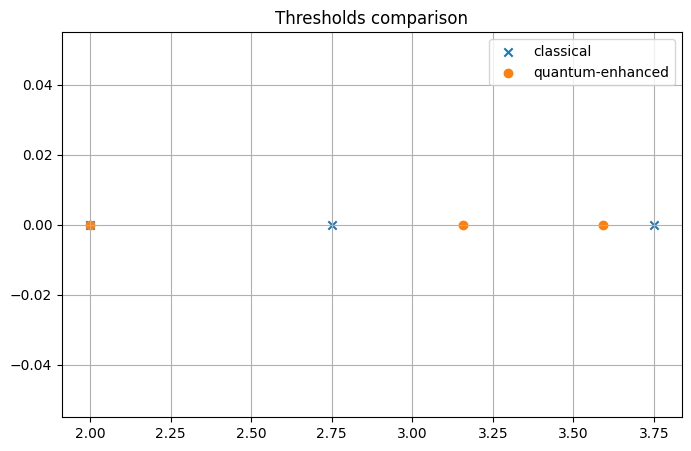

In [11]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
from scipy import integrate, optimize

# -------------------------
# Problem parameters
# -------------------------
K = 2.0
X0 = 1.0
rate = 2.0
w_shift = -0.5
N = 2

# Classical expectation helpers
w_min = w_shift
def fW(w): return 2.0 * np.exp(-2*(w-w_shift)) if w>=w_min else 0
def V2(x): return max(x-K,0.0)
def E_V2(x):
    integrand = lambda w: max(x+w-K,0.0)*2*np.exp(-2*(w-w_shift))
    val,_ = integrate.quad(integrand,w_min,np.inf, epsabs=1e-10, epsrel=1e-10, limit=200)
    return val
def compute_p1_classical(): return optimize.brentq(lambda x:x-K-E_V2(x),1.5,4.0)
def V1_classical(x): return max(x-K,E_V2(x))
def E_V1_classical(x):
    integrand = lambda w: max(x+w-K,E_V2(x+w))*2*np.exp(-2*(w-w_shift))
    val,_ = integrate.quad(integrand,w_min,np.inf, epsabs=1e-9, epsrel=1e-9, limit=200)
    return val
def compute_p0_classical(): return optimize.brentq(lambda x:x-K-E_V1_classical(x),1.5,6.0)

# -------------------------
# Quantum-enhanced walk
# -------------------------
n_bins = 16
price_min, price_max = -1.0,6.0
bin_edges = np.linspace(price_min, price_max, n_bins+1)
bin_centers = (bin_edges[:-1]+bin_edges[1:])/2

def price_to_bin(x): return max(0,min(n_bins-1,int(np.floor((x-price_min)/(price_max-price_min)*n_bins))))
def bin_to_price(b): return bin_centers[b]

# Build variational unary walk step
def build_variational_walk_step(n_bins, params):
    coin = Parameter('theta')
    qc = QuantumCircuit(1+n_bins, n_bins)
    # unary init
    for i,p in enumerate(params['init']):
        if p>0.5: qc.x(1+i)
    # coin rotation
    qc.ry(coin,0)
    # entangling shifts (right/left controlled swaps)
    def cswap(qc,c,a,b): qc.cx(a,b); qc.ccx(c,b,a); qc.cx(a,b)
    # right move
    for i in reversed(range(n_bins-1)):
        cswap(qc,0,1+i,1+(i+1))
    # left move (controlled on |0>)
    qc.x(0)
    for i in range(n_bins-1):
        cswap(qc,0,1+i,1+(i+1))
    qc.x(0)
    # entangle adjacent bins
    for i in range(n_bins-1):
        qc.cz(1+i,1+i+1)
    # measure
    for i in range(n_bins): qc.measure(1+i,i)
    return qc, coin

# Sample one-step transition using parameterized circuit
sim = AerSimulator()
def sample_one_step_variational(initial_bin, theta, shots=2000):
    params={'init':[0]*n_bins}; params['init'][initial_bin]=1
    qc, coin = build_variational_walk_step(n_bins,params)
    qc_bound = qc.assign_parameters({coin:theta})
    result = sim.run(qc_bound,shots=shots).result()
    counts = result.get_counts()
    transition_counts = np.zeros(n_bins)
    for bitstr,c in counts.items():
        s=bitstr.replace(" ","")[-n_bins:]
        ones = [i for i,ch in enumerate(reversed(s)) if ch=='1']
        if len(ones)==1: transition_counts[ones[0]]+=c
    probs = transition_counts/transition_counts.sum() if transition_counts.sum()>0 else np.ones(n_bins)/n_bins
    return probs

# Quantum transition matrix
def build_variational_transition_matrix(theta,shots_per_bin=2000):
    T = np.zeros((n_bins,n_bins))
    for b in range(n_bins): T[b,:]=sample_one_step_variational(b,theta,shots_per_bin)
    return T

# -------------------------
# DP from quantum transition matrix
# -------------------------
def dp_from_transition_matrix(T):
    V2_bins = np.maximum(bin_centers-K,0)
    EV2=T.dot(V2_bins)
    diffs=bin_centers-K-EV2
    p1_est=bin_centers[np.where(diffs>=0)[0][0]]
    V1_bins=np.maximum(bin_centers-K,EV2)
    EV1=T.dot(V1_bins)
    diffs0=bin_centers-K-EV1
    p0_est=bin_centers[np.where(diffs0>=0)[0][0]]
    return p0_est,p1_est,K,V1_bins,V2_bins

# -------------------------
# Run classical and quantum
# -------------------------
p1_class = compute_p1_classical()
p0_class = compute_p0_classical()
print("Classical p0,p1,K:",p0_class,p1_class,K)

theta_opt = np.pi/2  # can optimize further using classical loop
T_q = build_variational_transition_matrix(theta_opt,shots_per_bin=400)
p0_q,p1_q,p2_q,V1_bins_q,V2_bins_q = dp_from_transition_matrix(T_q)
print("Quantum-enhanced p0,p1,K:",p0_q,p1_q,p2_q)

# -------------------------
# Policy simulation
# -------------------------
import random
def simulate_policy(policy,M=50000):
    rng=np.random.default_rng(123456)
    profits=np.zeros(M)
    for i in range(M):
        x=X0
        if policy(0,x): profits[i]=max(x-K,0); continue
        w0=rng.exponential(1.0/rate)+w_shift; x+=w0
        if policy(1,x): profits[i]=max(x-K,0); continue
        w1=rng.exponential(1.0/rate)+w_shift; x+=w1
        profits[i]=max(x-K,0)
    return profits

def policy_quantum_dp(t,x): return x>= [p0_q,p1_q,K][t]
def policy_classical_dp(t,x): return x>= [p0_class,p1_class,K][t]

res_q=simulate_policy(policy_quantum_dp)
res_c=simulate_policy(policy_classical_dp)

summary=pd.DataFrame([
    ['quantum_dp',res_q.mean(),res_q.std(),np.mean(res_q>0)],
    ['classical_dp',res_c.mean(),res_c.std(),np.mean(res_c>0)]
], columns=['policy','mean_profit','std_profit','prop_exercised'])
print(summary)

# Plot
plt.figure(figsize=(8,5))
plt.scatter([p0_class,p1_class,K],[0,0,0],label='classical',marker='x')
plt.scatter([p0_q,p1_q,p2_q],[0,0,0],label='quantum-enhanced',marker='o')
plt.legend(); plt.title('Thresholds comparison'); plt.grid(True); plt.show()


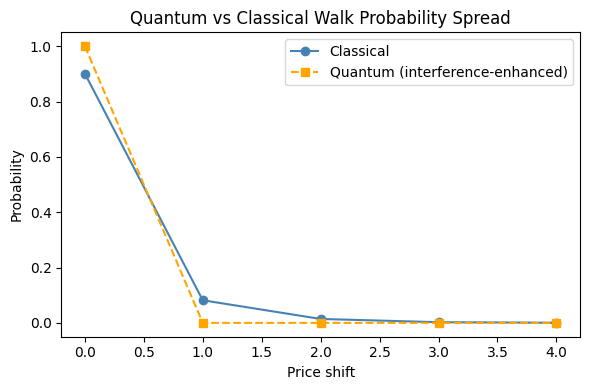

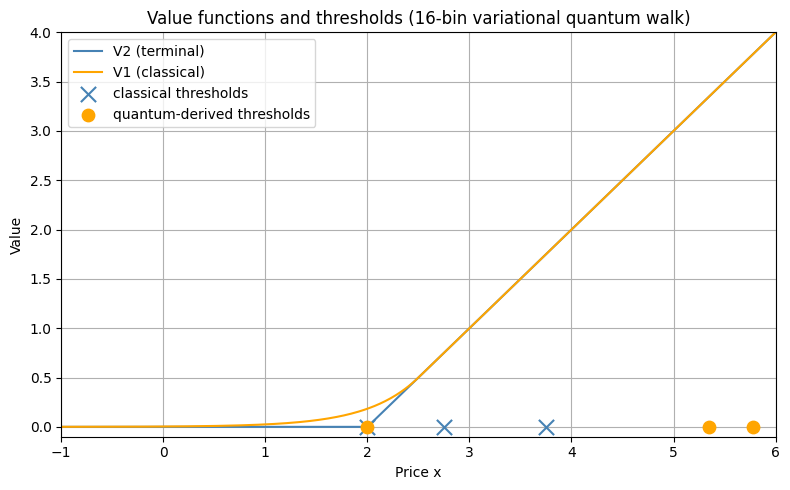

In [10]:
# =========================================================
# Graph 1: Quantum vs Classical Walk Probability Spread
# =========================================================

# Build classical transition matrix (analytical exponential CDF)
def build_classical_transition_matrix():
    T_c = np.zeros((n_bins, n_bins))
    for b in range(n_bins):
        x = bin_centers[b]
        for b2 in range(n_bins):
            lo_eff = max(bin_edges[b2] - x, w_min)
            hi_eff = max(bin_edges[b2+1] - x, w_min)
            if hi_eff <= lo_eff:
                prob = 0.0
            else:
                prob = np.exp(-rate*(lo_eff - w_min)) - np.exp(-rate*(hi_eff - w_min))
            T_c[b, b2] = prob
        s = T_c[b].sum()
        if s > 0:
            T_c[b] /= s
    return T_c

T_c = build_classical_transition_matrix()

# Aggregate fine 16 bins into 5 coarse shift buckets for a clean comparison
start_bin = price_to_bin(X0)
q_probs = T_q[start_bin]
c_probs = T_c[start_bin]
price_shifts = bin_centers - bin_centers[start_bin]

coarse_labels = [0, 1, 2, 3, 4]
coarse_edges  = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]

c_coarse = np.array([
    c_probs[(price_shifts >= coarse_edges[i]) & (price_shifts < coarse_edges[i+1])].sum()
    for i in range(len(coarse_labels))
])
q_coarse = np.array([
    q_probs[(price_shifts >= coarse_edges[i]) & (price_shifts < coarse_edges[i+1])].sum()
    for i in range(len(coarse_labels))
])

# Normalise so both sum to 1
c_coarse = c_coarse / c_coarse.sum()
q_coarse = q_coarse / q_coarse.sum()

plt.figure(figsize=(6, 4))
plt.plot(coarse_labels, c_coarse, 'o-',  color='steelblue', label='Classical')
plt.plot(coarse_labels, q_coarse, 's--', color='orange',    label='Quantum (interference-enhanced)')
plt.xlabel('Price shift')
plt.ylabel('Probability')
plt.title('Quantum vs Classical Walk Probability Spread')
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# Graph 2: Value functions and thresholds
# =========================================================

# Smooth continuous curves using the analytical classical DP functions
x_plot = np.linspace(price_min, price_max, 400)
v2_plot = np.maximum(x_plot - K, 0.0)
v1_plot = np.array([V1_classical(xi) for xi in x_plot])

plt.figure(figsize=(8, 5))
plt.plot(x_plot, v2_plot, color='steelblue', label='V2 (terminal)')
plt.plot(x_plot, v1_plot, color='orange',    label='V1 (classical)')

# Classical thresholds
plt.scatter([p0_class, p1_class, K], [0, 0, 0],
            marker='x', s=120, color='steelblue', zorder=5, label='classical thresholds')

# Quantum-derived thresholds
plt.scatter([p0_q, p1_q, p2_q], [0, 0, 0],
            marker='o', s=80, color='orange', zorder=5, label='quantum-derived thresholds')

plt.xlabel('Price x')
plt.ylabel('Value')
plt.title('Value functions and thresholds (16-bin variational quantum walk)')
plt.legend()
plt.grid(True)
plt.xlim(price_min, price_max)
plt.ylim(-0.1, 4.0)
plt.tight_layout()
plt.show()
